In [1]:
import numpy as np

# Van der Pol

In [ ]:
import sympy as smp

## Symbolic solution

In [82]:
x1, x2, mu, w, t, alp, F= smp.symbols(r'x_1 x_2 \mu \omega t \alpha \mathcal{F}')

sin = (w*t) - (w*t)**3/(3*2) #+ (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

dx1 = x2
dx2 = -x1 + mu*x2*(1-x1**2) + alp*sin
dt = 1

### Jacobian about origin

In [83]:
Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
                  [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])
Jac

Matrix([
[                 0,                1,                                   0],
[-2*\mu*x_1*x_2 - 1, \mu*(1 - x_1**2), \alpha*(-\omega**3*t**2/2 + \omega)],
[                 0,                0,                                   0]])

In [84]:
J0 = Jac.subs([[x1,0],[x2,0],[mu,1]])
J0

Matrix([
[ 0, 1,                                   0],
[-1, 1, \alpha*(-\omega**3*t**2/2 + \omega)],
[ 0, 0,                                   0]])

In [135]:
J0.eigenvects()

[(0,
  1,
  [Matrix([
   [-\alpha*\omega**3*t**2/2 + \alpha*\omega],
   [                                       0],
   [                                       1]])]),
 (1/2 - sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 + sqrt(3)*I/2],
   [                1],
   [                0]])]),
 (1/2 + sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 - sqrt(3)*I/2],
   [                1],
   [                0]])])]

In [86]:
J0.eigenvals()

{0: 1, 1/2 - sqrt(3)*I/2: 1, 1/2 + sqrt(3)*I/2: 1}

### Transform

In [87]:
ev1 = J0.eigenvects()[0][2][0]
ev2 = J0.eigenvects()[1][2][0]
ev3 = J0.eigenvects()[2][2][0]
ev1

Matrix([
[-\alpha*\omega**3*t**2/2 + \alpha*\omega],
[                                       0],
[                                       1]])

In [88]:
P = smp.Matrix([[ev1.T],
               [ev2.T],
               [ev3.T]]).T
P

Matrix([
[-\alpha*\omega**3*t**2/2 + \alpha*\omega, 1/2 + sqrt(3)*I/2, 1/2 - sqrt(3)*I/2],
[                                       0,                 1,                 1],
[                                       1,                 0,                 0]])

In [89]:
c, s, u = smp.symbols('c s u')

P_inv = P.inv()
csu = smp.Matrix([c,s,u])
xyt_dot = smp.Matrix([dx1,dx2,dt])

In [90]:
trans = P@csu
trans

Matrix([
[c*(-\alpha*\omega**3*t**2/2 + \alpha*\omega) + s*(1/2 + sqrt(3)*I/2) + u*(1/2 - sqrt(3)*I/2)],
[                                                                                       s + u],
[                                                                                           c]])

In [91]:
csu_dot = P_inv@xyt_dot
csu_dot

Matrix([
[                                                                                                                                                                          1],
[-sqrt(3)*I*\alpha*\omega**3*t**2/6 + sqrt(3)*I*\alpha*\omega/3 - sqrt(3)*I*x_2/3 + (1/2 + sqrt(3)*I/6)*(\alpha*(-\omega**3*t**3/6 + \omega*t) + \mu*x_2*(1 - x_1**2) - x_1)],
[ sqrt(3)*I*\alpha*\omega**3*t**2/6 - sqrt(3)*I*\alpha*\omega/3 + sqrt(3)*I*x_2/3 + (1/2 - sqrt(3)*I/6)*(\alpha*(-\omega**3*t**3/6 + \omega*t) + \mu*x_2*(1 - x_1**2) - x_1)]])

In [92]:
csu_dot = csu_dot.subs([[x1,trans[0]],
                       [x2,trans[1]],
                       [t,trans[2]]])

### Manifold

In [93]:
dc = csu_dot[0].expand()
ds = csu_dot[1].expand()
du = csu_dot[2].expand()

In [94]:
A = dc.coeff(c,1).coeff(s,0).coeff(u,0).coeff(alp,0)
A

0

In [95]:
g1 = dc - A*c
g1

1

In [96]:
b1 = ds.coeff(c,0).coeff(s,1).coeff(u,0).coeff(alp,0)
b2 = du.coeff(c,0).coeff(s,0).coeff(u,1).coeff(alp,0)

B = smp.Matrix([[b1,0],
                [0,b2]])
B

Matrix([
[\mu/2 + sqrt(3)*I*\mu/6 - 2*sqrt(3)*I/3,                                       0],
[                                      0, \mu/2 - sqrt(3)*I*\mu/6 + 2*sqrt(3)*I/3]])

In [97]:
g2_1 = ds - b1*s
g2_2 = du - b2*u
g2 = smp.Matrix([g2_1,g2_2])
g2

Matrix([
[-\alpha**2*\mu*\omega**6*c**6*s/8 - sqrt(3)*I*\alpha**2*\mu*\omega**6*c**6*s/24 - \alpha**2*\mu*\omega**6*c**6*u/8 - sqrt(3)*I*\alpha**2*\mu*\omega**6*c**6*u/24 + \alpha**2*\mu*\omega**4*c**4*s/2 + sqrt(3)*I*\alpha**2*\mu*\omega**4*c**4*s/6 + \alpha**2*\mu*\omega**4*c**4*u/2 + sqrt(3)*I*\alpha**2*\mu*\omega**4*c**4*u/6 - \alpha**2*\mu*\omega**2*c**2*s/2 - sqrt(3)*I*\alpha**2*\mu*\omega**2*c**2*s/6 - \alpha**2*\mu*\omega**2*c**2*u/2 - sqrt(3)*I*\alpha**2*\mu*\omega**2*c**2*u/6 + sqrt(3)*I*\alpha*\mu*\omega**3*c**3*s**2/3 + \alpha*\mu*\omega**3*c**3*s*u/2 + sqrt(3)*I*\alpha*\mu*\omega**3*c**3*s*u/6 + \alpha*\mu*\omega**3*c**3*u**2/2 - sqrt(3)*I*\alpha*\mu*\omega**3*c**3*u**2/6 - 2*sqrt(3)*I*\alpha*\mu*\omega*c*s**2/3 - \alpha*\mu*\omega*c*s*u - sqrt(3)*I*\alpha*\mu*\omega*c*s*u/3 - \alpha*\mu*\omega*c*u**2 + sqrt(3)*I*\alpha*\mu*\omega*c*u**2/3 + \alpha*\omega**3*c**3/6 + sqrt(3)*I*\alpha*\omega**3*c**3/18 - sqrt(3)*I*\alpha*\omega**3*c**2/6 + sqrt(3)*I*\alpha*\omega/3 + \mu*s*

In [98]:
k1, k2, k3, b1, b2, b3 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \beta_1 \beta_2 \beta_3')

h1 = k1*c**2 + k2*c*alp + k3*alp**2
h2 = b1*c**2 + b2*c*alp + b3*alp**2

H = smp.Matrix([h1,h2])
Dh = smp.diff(H,c)

In [99]:
N = Dh*(A*c + g1) - B@H - g2
N = N.subs([[s,h1],[u,h2]]).expand()
N

Matrix([
[-sqrt(3)*I*\alpha**6*\beta_3**3*\mu/3 + \alpha**6*\beta_3**2*\kappa_3*\mu + \alpha**6*\beta_3*\kappa_3**2*\mu/2 + sqrt(3)*I*\alpha**6*\beta_3*\kappa_3**2*\mu/2 - \alpha**6*\kappa_3**3*\mu/2 + sqrt(3)*I*\alpha**6*\kappa_3**3*\mu/6 - sqrt(3)*I*\alpha**5*\beta_2*\beta_3**2*\mu*c + 2*\alpha**5*\beta_2*\beta_3*\kappa_3*\mu*c + \alpha**5*\beta_2*\kappa_3**2*\mu*c/2 + sqrt(3)*I*\alpha**5*\beta_2*\kappa_3**2*\mu*c/2 + \alpha**5*\beta_3**2*\kappa_2*\mu*c - \alpha**5*\beta_3**2*\mu*\omega**3*c**3/2 + sqrt(3)*I*\alpha**5*\beta_3**2*\mu*\omega**3*c**3/6 + \alpha**5*\beta_3**2*\mu*\omega*c - sqrt(3)*I*\alpha**5*\beta_3**2*\mu*\omega*c/3 + \alpha**5*\beta_3*\kappa_2*\kappa_3*\mu*c + sqrt(3)*I*\alpha**5*\beta_3*\kappa_2*\kappa_3*\mu*c - \alpha**5*\beta_3*\kappa_3*\mu*\omega**3*c**3/2 - sqrt(3)*I*\alpha**5*\beta_3*\kappa_3*\mu*\omega**3*c**3/6 + \alpha**5*\beta_3*\kappa_3*\mu*\omega*c + sqrt(3)*I*\alpha**5*\beta_3*\kappa_3*\mu*\omega*c/3 - 3*\alpha**5*\kappa_2*\kappa_3**2*\mu*c/2 + sqrt(3)*I

In [100]:
N1 = N[0]
N2 = N[1]

In [101]:
N1_c_pow2   = N1.coeff(c,2).coeff(alp,0)
N1_c_pow1   = N1.coeff(c,1).coeff(alp,0)
N1_c_alp    = N1.coeff(c,1).coeff(alp,1)
N1_alp_pow1 = N1.coeff(c,0).coeff(alp,1)
N1_alp_pow2 = N1.coeff(c,0).coeff(alp,2)

N2_c_pow2   = N2.coeff(c,2).coeff(alp,0)
N2_c_pow1   = N2.coeff(c,1).coeff(alp,0)
N2_c_alp    = N2.coeff(c,1).coeff(alp,1)
N2_alp_pow1 = N2.coeff(c,0).coeff(alp,1)
N2_alp_pow2 = N2.coeff(c,0).coeff(alp,2)

In [102]:
N1_c_pow1

2*\kappa_1

In [104]:
N2_c_pow1

2*\beta_1

In [103]:
N1_alp_pow1

\kappa_2 - sqrt(3)*I*\omega/3

In [105]:
N2_alp_pow1

\beta_2 + sqrt(3)*I*\omega/3

In [117]:
k2_sub = smp.solve(N1_alp_pow1,k2)[0]
b2_sub = smp.solve(N2_alp_pow1,b2)[0]

In [106]:
N1_c_pow2.subs([[b1,0],[k1,0]])

0

In [118]:
N1_c_alp = N1_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_c_alp

-\omega/2 - sqrt(3)*I*\omega/6

In [119]:
N1_alp_pow2 = N1_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_alp_pow2

-\beta_3*\mu/2 - sqrt(3)*I*\beta_3*\mu/6 + \beta_3/2 + sqrt(3)*I*\beta_3/6 - \kappa_3*\mu/2 - sqrt(3)*I*\kappa_3*\mu/6 + 2*sqrt(3)*I*\kappa_3/3

In [120]:
N2_c_pow2 = N2_c_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_pow2

0

In [121]:
N2_c_alp = N2_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_alp

-\omega/2 + sqrt(3)*I*\omega/6

In [131]:
N2_alp_pow2 = N2_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_alp_pow2

-\beta_3*\mu/2 + sqrt(3)*I*\beta_3*\mu/6 - \beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) + sqrt(3)*I*\beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - 2*sqrt(3)*I*\beta_3/3 + \beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - sqrt(3)*I*\beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3)))

In [132]:
smp.solve([N1_alp_pow2,N2_alp_pow2],[k3,b3])

{\beta_3: 0, \kappa_3: 0}

In [133]:
smp.solve([N1_c_alp,N2_c_alp],[w])

{\omega: 0}

In [44]:
N2.subs([[k1,0],
        [k2,0],
        [k3,0]])

-1

In [159]:
dx1_f = smp.lambdify([x1,x2,t,mu,alp,w],dx1)
dx2_f = smp.lambdify([x1,x2,t,mu,alp,w],dx2)

In [160]:
x1v = np.linspace(-10,10,20)/2
x2v = np.linspace(-10,10,20)/2

x1G, x2G = np.meshgrid(x1v,x2v)

In [183]:
mu_val = 1
w_val = 1.2
a_val = 0
F_val = np.linspace(0,1,25)
t_val = np.linspace(0,10*np.pi,1000)

## Numerical solution

In [2]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact

In [3]:
clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']

In [4]:
def poincare(data,t,border,plot_y = True):
    if plot_y ==True:
        x, y = data
        xlim, ylim = border
    else:
        y, x = data
        ylim, xlim = border

    x_mapped = np.where(np.round(x,0)==xlim)[0]
    y = y[x_mapped]
    t_poin = t[x_mapped]
    y_mapped = np.where(y>ylim[0])[0]
    y = y[y_mapped]
    t_poin = t_poin[y_mapped]
    
    return [t_poin,y]
    

Eigenvalue pair

$$\frac{\mu}{2} \pm \frac{\sqrt{(\mu - 2)*(\mu + 2)}}{2}$$

When $\mu=1$

$$\frac{1}{2} \pm \frac{\sqrt{3}}{2}\mathcal{i}$$

In [36]:
w = 1.2
A_space = np.arange(0,1.02,0.05)
kick_time = np.linspace(2*np.pi/w,4*np.pi/w,8)

def kick(t,t0,A):
    sigma = 0.2
    return A/(np.sqrt(2*np.pi)*sigma)*np.exp(-((t-t0)/sigma)**2/2)

def force(t,A):
    return A*np.sin(w*t)


def sys(S,t):
    x1, x2 = S
    
    mu = 1
    AF = A_space[4]
    Ak = 0
    t0 = kick_time[0]

    
    dx1 = x2 
    dx2 = force(t,AF) + mu*x2*(1-x1**2)-x1 + kick(t,t0,Ak)
    
    return [dx1,dx2]

In [37]:
T0 = 2*np.pi/(np.sqrt(3)/2)

In [38]:
t = np.linspace(0,5*T0,10000)

X0 = [0,1]

SS = [2.0086198296834326,0]
# SS

soln = odeint(sys,SS,t).T

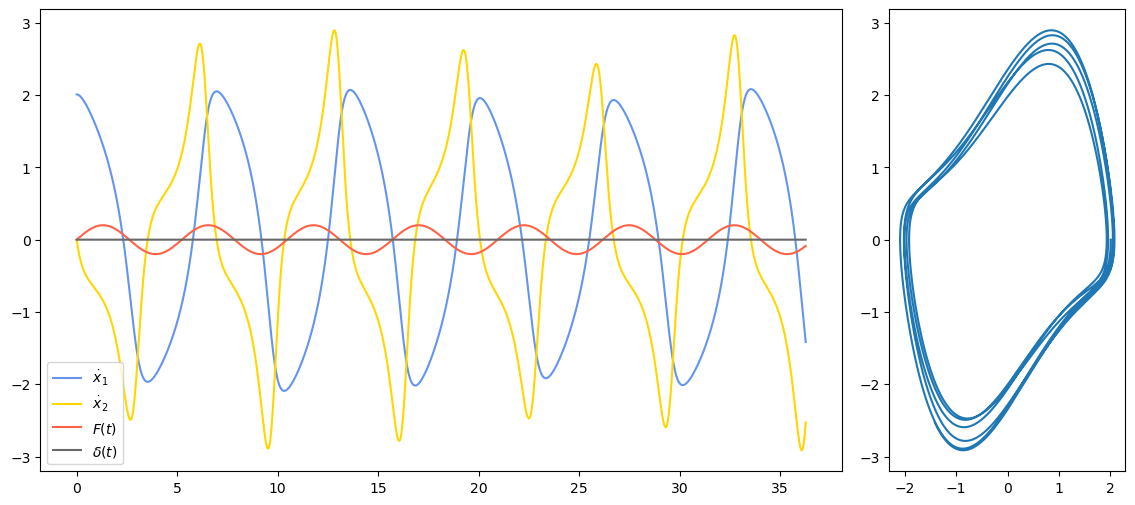

In [39]:
fig = plt.figure(figsize=(14,6))

gs = gridspec.GridSpec(1,4)

p1 = fig.add_subplot(gs[:3])
p2 = fig.add_subplot(gs[3:])


p1.plot(t,soln[0],color=clr[0],label=r'$\dot x_1$')
p1.plot(t,soln[1],color=clr[1],label=r'$\dot x_2$')
p1.plot(t,force(t,A_space[4]),color=clr[2],label=r'$F(t)$')
p1.plot(t,kick(t,kick_time[0],0),color=clr[-1],label=r'$\delta(t)$')



p1.legend()

p2.plot(soln[0],soln[1])
# p2.set_xlim([1.8,2.1])
# p2.set_ylim([-0.5,0.5])
# p2.vlines(0,ymin=ylim[0],ymax=ylim[1],color=clr[-1],linestyle='--')



plt.show()

### Adjoint

In [9]:
x, y = odeint(sys,SS,t).T

dx = np.diff(x)

filt = np.where(dx<=0)[0]
x_phase = x[filt]
y_phase = y[filt]

theta0 = np.where(np.diff(filt)>1)[0][-3]
thetaf = np.where(np.diff(filt)>1)[0][-2]

limCycle = np.array([[x[theta0:thetaf]],
                     [y[theta0:thetaf]]])

In [10]:
theta0

2754

In [11]:
thetaf

3672

In [29]:
def get_limCycle(sys,x0,t):
    x, y = odeint(sys,SS,t).T

    dx = np.diff(x)

    idx = np.where(dx<=0)[0]

    # x_map = x[test]
    # y_map = y[test]
    # t_map = t[test]

    jump = np.where(np.diff(idx)>1)[0]

    idx = idx[jump+1]

    theta0 = idx[-3]
    thetaf = idx[-2]

    # x_map = x[idx]
    # y_map = y[idx]
    # t_map = t[idx]

    T = t[thetaf] - t[theta0]

    limCycle = [x[theta0:thetaf],
               y[theta0:thetaf],
               T]
    
    return limCycle

In [30]:
limCycle = get_limCycle(sys,SS,t)

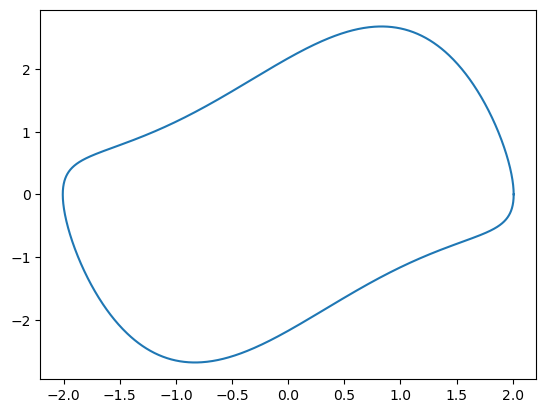

In [31]:
plt.plot(limCycle[0],limCycle[1])

In [22]:
x = soln[0]
y = soln[1]

dx = np.diff(x)

idx = np.where(dx<=0)[0]

# x_map = x[test]
# y_map = y[test]
# t_map = t[test]

jump = np.where(np.diff(idx)>1)[0]

idx = idx[jump+1]

theta0 = idx[-3]
thetaf = idx[-2]

x_map = x[idx]
y_map = y[idx]
t_map = t[idx]

T = t[thetaf] - t[theta0]

limCycle = [x[theta0:thetaf],
           y[theta0:thetaf],
           T]

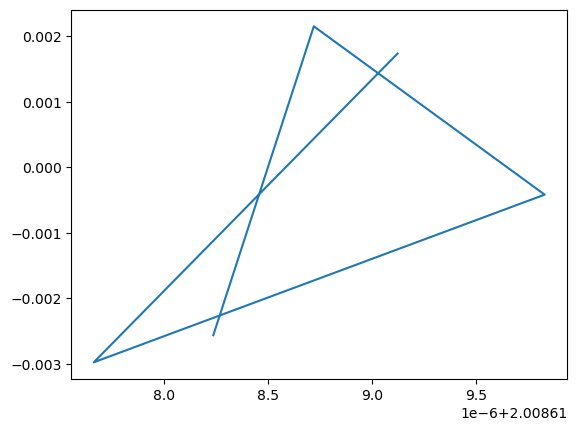

In [23]:
plt.plot(x_map,y_map)

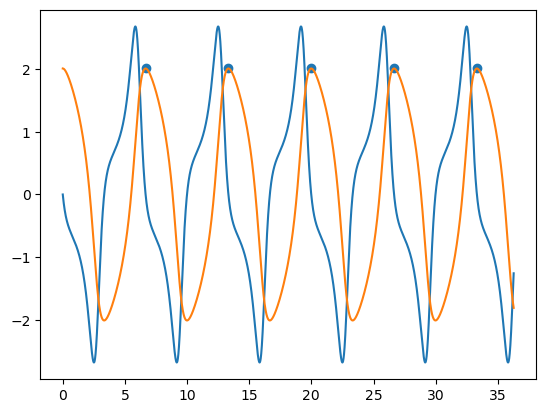

In [24]:
plt.plot(t,y)
plt.plot(t,x)
plt.scatter(t_map,x_map)

Text(0.5, 1.0, 'period: 6.664565320728588')

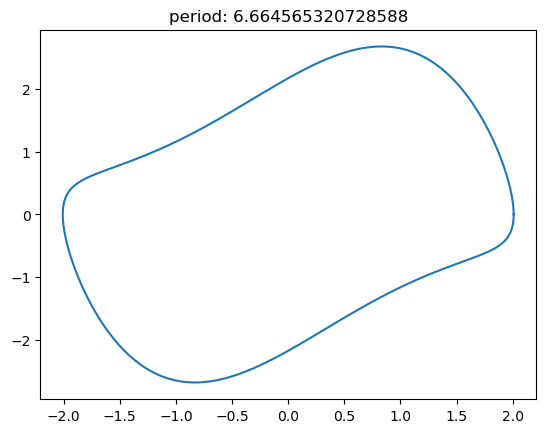

In [28]:
plt.plot(limCycle[0],limCycle[1])
plt.title(f'period: {limCycle[-1]}')

In [300]:
test[1]

[-1, 1]

# Duffing Oscillator

Unforced, undamped

$$\ddot{x} - x + x^3 =0$$  

When linearized

$$\begin{cases}\dot x_1 = x_2\\
\dot x_2 = x_1 - x_1^3 - \delta x_2\end{cases}$$

Modified equation [[ch 4, Wiggins]] 

$$\begin{cases}\dot x_1 = x_2\\
\dot x_2 = x_1 - x_1^3 - \delta x_2 + x_1^2x_2\end{cases}$$


Define symbolic system

In [114]:
x1, x2, dta, w, t, alp, F = smp.symbols(r'x_1 x_2 \delta \omega t \alpha \mathcal{F}')

dx1 = x2
dx2 = x1 - x1**3 - dta*x2 + alp*(F) + x1**2*x2

In [115]:
sin = (w*t) - (w*t)**3/(3*2) + (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

In [116]:
dx2 = dx2.subs(F,sin)

### Check Zeros

In [64]:
# fix_pnts = smp.solve([dx1,dx2],[x1,x2])
# fix_pnts

### Jac-ob

In [117]:
Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
                  [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])
Jac

Matrix([
[                        0,                1,                                                                            0],
[-3*x_1**2 + 2*x_1*x_2 + 1, -\delta + x_1**2, \alpha*(-\omega**7*t**6/720 + \omega**5*t**4/24 - \omega**3*t**2/2 + \omega)],
[                        0,                0,                                                                            0]])

In [118]:
J0 = Jac.subs([[x1,0],[x2,0],[dta,0]])
J0

Matrix([
[0, 1,                                                                            0],
[1, 0, \alpha*(-\omega**7*t**6/720 + \omega**5*t**4/24 - \omega**3*t**2/2 + \omega)],
[0, 0,                                                                            0]])

In [120]:
J0.eigenvects()

[(-1,
  1,
  [Matrix([
   [-1],
   [ 1],
   [ 0]])]),
 (0,
  1,
  [Matrix([
   [\alpha*\omega**7*t**6/720 - \alpha*\omega**5*t**4/24 + \alpha*\omega**3*t**2/2 - \alpha*\omega],
   [                                                                                             0],
   [                                                                                             1]])]),
 (1,
  1,
  [Matrix([
   [1],
   [1],
   [0]])])]

In [121]:
ev1 = J0.eigenvects()[1][2][0]
ev2 = J0.eigenvects()[0][2][0]
ev3 = J0.eigenvects()[2][2][0]

In [122]:
c, s, u = smp.symbols(r'c s u')

csu = smp.Matrix([c,s,u])
xxt = smp.Matrix([x1,x2,t])
P = smp.Matrix([[ev1.T],
                [ev2.T],
                [ev3.T]]).T
Pinv = P.inv()

In [123]:
trans = P@csu
trans

Matrix([
[c*(\alpha*\omega**7*t**6/720 - \alpha*\omega**5*t**4/24 + \alpha*\omega**3*t**2/2 - \alpha*\omega) - s + u],
[                                                                                                     s + u],
[                                                                                                         c]])

In [124]:
csu_dot = Pinv@xxt.subs([[x1,dx1],[x2,dx2],[t,dt]])
csu_dot

Matrix([
[                                                                                                                                                                                                            1],
[                                                                                                            \alpha*\omega**7*t**6/1440 - \alpha*\omega**5*t**4/48 + \alpha*\omega**3*t**2/4 - \alpha*\omega/2],
[-\alpha*\omega**7*t**6/1440 + \alpha*\omega**5*t**4/48 - \alpha*\omega**3*t**2/4 + \alpha*\omega/2 + \alpha*(-\omega**7/5040 + \omega**5/120 - \omega**3/6 + \omega) - \delta*x_2 - x_1**3 + x_1**2*x_2 + x_1]])

In [125]:
csu_dot = csu_dot.subs([[x1,trans[0]],
                        [x2,trans[1]],
                        [t,trans[2]]])
csu_dot

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             1],
[                                                                                                                                                                                                                                                                                                                                                                                                                                             \alpha*\omega**7*c**6/1440 - \a

In [126]:
dc = csu_dot[0].expand()
ds = csu_dot[1].expand()
du = csu_dot[2].expand()

In [127]:
A = dc.coeff(c,1).coeff(s,0).coeff(u,0)
g1 = A - dc*c

In [128]:
Bs = ds.coeff(c,0).coeff(s,1).coeff(u,0)
g2s = Bs - ds*s

In [129]:
Bu = du.coeff(c,0).coeff(s,0).coeff(u,1)
g2u = Bu - du*u

In [131]:
B = smp.Matrix([[Bs,0],[0,Bu]])
g2 = smp.Matrix([[g2s],[g2u]])
B

Matrix([
[0,          0],
[0, 1 - \delta]])

In [108]:
k1, k2, k3, k4, k5, k6 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \kappa_4 \kappa_5 \kappa_6')

h = k1*c**2 + k2*c**3 

\kappa_1